# Laboratorio 2 - Deep Learning
## LSTM y analisis de similitud con catch22

## 0. Configuracion y reproducibilidad

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pycatch22
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option('display.max_columns', 25)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

DEVICE = torch.device('cpu')
print("Semilla fijada:", SEED, "| Dispositivo:", DEVICE, "| Version de torch:", torch.__version__,
      "| pycatch22 disponible:", hasattr(pycatch22, 'catch22_all'))

Semilla fijada: 42 | Dispositivo: cpu | Version de torch: 2.13.0+cpu | pycatch22 disponible: True


## 1. Carga de los mismos conjuntos de entrenamiento y prueba del Laboratorio 1

`train_raw.csv` y `test_raw.csv` son los archivos guardados por el notebook del Laboratorio 1
(`Lab1_Series_de_Tiempo.ipynb`, seccion 9) a partir del corte temporal 70/30 en `2021-04-01`.
Cargarlos directamente, en vez de repetir el split, asegura que se trabaja con **exactamente** los
mismos datos de entrenamiento y prueba pedidos por el enunciado del Laboratorio 2.

In [2]:
train_raw = pd.read_csv('train_raw.csv')
test_raw = pd.read_csv('test_raw.csv')
train_raw['fecha'] = pd.to_datetime(train_raw['fecha'])
test_raw['fecha'] = pd.to_datetime(test_raw['fecha'])

print("Entrenamiento:", train_raw['fecha'].min().date(), "a", train_raw['fecha'].max().date(), "-", train_raw.shape)
print("Prueba:       ", test_raw['fecha'].min().date(), "a", test_raw['fecha'].max().date(), "-", test_raw.shape)

Entrenamiento: 2009-01-01 a 2021-03-01 - (131442, 15)
Prueba:        2021-04-01 a 2026-06-01 - (29594, 15)


## 2. Reconstruccion de las 8 series de tiempo del Laboratorio 1

Se construyen las 8 series (idéntica logica a la del Laboratorio 1: agregacion mensual de `Viajero`,
frecuencia `MS`, sin huecos) en dos versiones:

- **Train / test por separado** (147 / 63 meses): se usan para entrenar y evaluar todos los modelos LSTM
  de este notebook (Ejercicio 1 y el punto 2.14 del Ejercicio 2), evitando cualquier fuga de informacion
  del periodo de prueba.
- **Serie completa** (train + test concatenado, 210 meses, 2009-01 a 2026-06): se usa solo para el
  analisis exploratorio de similitud con catch22 (puntos 2.2-2.13), donde el objetivo es caracterizar el
  comportamiento real de cada serie y no evaluar capacidad predictiva.

In [3]:
def construir_serie(data, filtro=None, rango_completo=None):
    '''Agrega Viajero por mes y devuelve una serie con frecuencia mensual completa (sin huecos).
    Misma funcion utilizada en el Laboratorio 1.'''
    d = data if filtro is None else data[filtro]
    serie = d.groupby('fecha')['Viajero'].sum()
    if rango_completo is not None:
        serie = serie.reindex(rango_completo, fill_value=0)
    serie.index.freq = 'MS'
    return serie

rango_train = pd.date_range(train_raw['fecha'].min(), train_raw['fecha'].max(), freq='MS')
rango_test = pd.date_range(test_raw['fecha'].min(), test_raw['fecha'].max(), freq='MS')
vias = ['Aérea', 'Terrestre', 'Marítima']
tipos = ['Turista', 'Excursionista', 'Cruceristas', 'Viajero']

series_train, series_test = {}, {}
filtro_te_train = train_raw['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
filtro_te_test = test_raw['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
series_train['Total (obligatoria)'] = construir_serie(train_raw, filtro_te_train, rango_train)
series_test['Total (obligatoria)'] = construir_serie(test_raw, filtro_te_test, rango_test)
for via in vias:
    series_train[f'Via {via}'] = construir_serie(train_raw, train_raw['Vía'] == via, rango_train)
    series_test[f'Via {via}'] = construir_serie(test_raw, test_raw['Vía'] == via, rango_test)
for tipo in tipos:
    series_train[f'Tipo {tipo}'] = construir_serie(train_raw, train_raw['Tipo de Viajero'] == tipo, rango_train)
    series_test[f'Tipo {tipo}'] = construir_serie(test_raw, test_raw['Tipo de Viajero'] == tipo, rango_test)

print(f"Entrenamiento: {rango_train.min().date()} a {rango_train.max().date()} ({len(rango_train)} meses)")
print(f"Prueba:        {rango_test.min().date()} a {rango_test.max().date()} ({len(rango_test)} meses)")
print("\nSeries construidas (train/test):", list(series_train.keys()))

Entrenamiento: 2009-01-01 a 2021-03-01 (147 meses)
Prueba:        2021-04-01 a 2026-06-01 (63 meses)

Series construidas (train/test): ['Total (obligatoria)', 'Via Aérea', 'Via Terrestre', 'Via Marítima', 'Tipo Turista', 'Tipo Excursionista', 'Tipo Cruceristas', 'Tipo Viajero']


In [4]:
df_completo = pd.concat([train_raw, test_raw], ignore_index=True)
rango_completo = pd.date_range(df_completo['fecha'].min(), df_completo['fecha'].max(), freq='MS')

series_completas = {}
filtro_te = df_completo['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
series_completas['Total (obligatoria)'] = construir_serie(df_completo, filtro_te, rango_completo)
for via in vias:
    series_completas[f'Via {via}'] = construir_serie(df_completo, df_completo['Vía'] == via, rango_completo)
for tipo in tipos:
    series_completas[f'Tipo {tipo}'] = construir_serie(df_completo, df_completo['Tipo de Viajero'] == tipo, rango_completo)

print(f"Rango completo: {rango_completo.min().date()} a {rango_completo.max().date()} ({len(rango_completo)} meses)\n")
for nombre, s in series_completas.items():
    print(f"{nombre:22s}: {len(s)} meses, ceros={int((s==0).sum())}, media={s.mean():,.0f}, max={s.max():,.0f}")

Rango completo: 2009-01-01 a 2026-06-01 (210 meses)

Total (obligatoria)   : 210 meses, ceros=0, media=222,438, max=449,114
Via Aérea             : 210 meses, ceros=0, media=90,780, max=158,463
Via Terrestre         : 210 meses, ceros=0, media=152,359, max=357,685
Via Marítima          : 210 meses, ceros=27, media=5,851, max=29,506
Tipo Turista          : 210 meses, ceros=0, media=179,251, max=344,011
Tipo Excursionista    : 210 meses, ceros=5, media=43,187, max=114,525
Tipo Cruceristas      : 210 meses, ceros=87, media=5,259, max=29,506
Tipo Viajero          : 210 meses, ceros=5, media=21,293, max=128,246


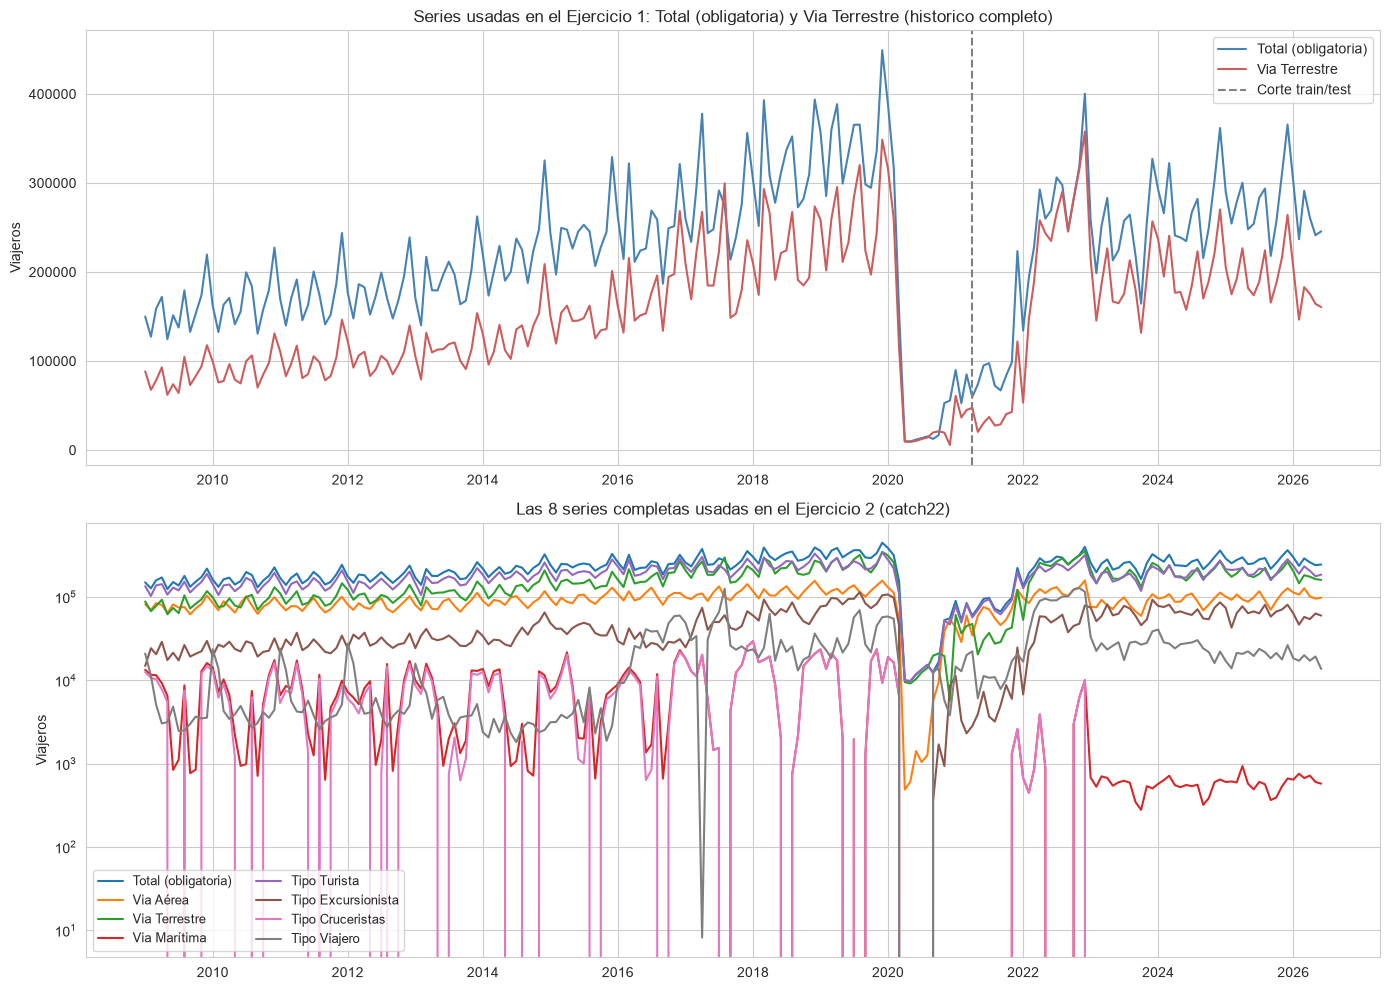

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(series_completas['Total (obligatoria)'].index, series_completas['Total (obligatoria)'].values,
             color='steelblue', label='Total (obligatoria)')
axes[0].plot(series_completas['Via Terrestre'].index, series_completas['Via Terrestre'].values,
             color='indianred', label='Via Terrestre')
axes[0].axvline(series_test['Total (obligatoria)'].index.min(), color='gray', linestyle='--', label='Corte train/test')
axes[0].set_title('Series usadas en el Ejercicio 1: Total (obligatoria) y Via Terrestre (historico completo)')
axes[0].set_ylabel('Viajeros')
axes[0].legend()

for nombre, s in series_completas.items():
    axes[1].plot(s.index, s.values, label=nombre)
axes[1].set_title('Las 8 series completas usadas en el Ejercicio 2 (catch22)')
axes[1].set_ylabel('Viajeros')
axes[1].set_yscale('log')
axes[1].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

## 3. Preprocesamiento comun para LSTM

Funciones compartidas por el Ejercicio 1 y el punto 2.14 del Ejercicio 2. Igual que en el Laboratorio 1,
la varianza de estas series crece con el nivel, asi que aplicamos **log1p** antes de escalar (soporta
ceros). Despues normalizamos a `[0,1]` con `MinMaxScaler` **ajustado solo con el entrenamiento**, para no
filtrar informacion del conjunto de prueba. Las redes LSTM se entrenan con ventanas deslizantes
(`lookback` meses pasados -> siguiente mes), y el pronostico sobre el conjunto de prueba se hace de
forma **recursiva**: cada prediccion se reinyecta como entrada para predecir el siguiente mes.

In [6]:
def preparar_escalador(serie_train):
    '''log1p + MinMaxScaler ajustado solo con el entrenamiento.'''
    log_train = np.log1p(serie_train.values.reshape(-1, 1))
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_train = scaler.fit_transform(log_train).flatten()
    return scaled_train, scaler

def desescalar(scaler, valores_escalados):
    valores_escalados = np.asarray(valores_escalados).reshape(-1, 1)
    log_vals = scaler.inverse_transform(valores_escalados).flatten()
    return np.expm1(log_vals)

def crear_ventanas(serie_escalada, lookback):
    X, y = [], []
    for i in range(lookback, len(serie_escalada)):
        X.append(serie_escalada[i - lookback:i])
        y.append(serie_escalada[i])
    return np.array(X), np.array(y)

def metricas(real, pred):
    real = np.asarray(real); pred = np.asarray(pred)
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred) ** 2))
    return mae, rmse

def pronosticar_recursivo(modelo, ultima_ventana_escalada, h, catch22_vec=None):
    '''Pronostica h pasos adelante reinyectando cada prediccion como entrada del siguiente paso.
    Si se pasa catch22_vec, el modelo espera dos entradas (ventana + caracteristicas catch22).'''
    modelo.eval()
    lookback = len(ultima_ventana_escalada)
    ventana = list(ultima_ventana_escalada)
    c = None if catch22_vec is None else torch.tensor(catch22_vec, dtype=torch.float32).view(1, -1).to(DEVICE)
    predicciones = []
    with torch.no_grad():
        for _ in range(h):
            x = torch.tensor(ventana[-lookback:], dtype=torch.float32).view(1, -1, 1).to(DEVICE)
            pred = modelo(x, c).item() if c is not None else modelo(x).item()
            predicciones.append(pred)
            ventana.append(pred)
    return np.array(predicciones)

print("Funciones de preprocesamiento y pronostico definidas.")

Funciones de preprocesamiento y pronostico definidas.
